# Working with Universal Robots via RTDE

This notebook introduces the RTDE-based workflow for Universal Robots in RobotBlockSet. Its purpose is to show how to connect to, monitor, and control Universal Robots using the RTDE interface.


## What this notebook covers

The examples below demonstrate the main steps for working with Universal Robots through RTDE, including initialization, state capture, command execution, and inspection of robot motion and feedback signals during runtime.

Use this notebook as a practical starting point when you want to control a Universal Robot from RobotBlockSet through the RTDE interface or adapt the same workflow to your own setup.


# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from robotblockset.transformations import map_pose, q_wxyz2xyzw, q_xyzw2wxyz

np.set_printoptions(formatter={"float": "{: 0.4f}".format})

ur_rtde and the dashboard client can emit useful runtime messages


In [ ]:
import logging
logging.basicConfig(level=logging.INFO)

## Helper function for capturing robot states

The following function stores robot time, joint states, task-space states, and commanded references during motion. These recorded arrays are later used for plotting.


Capture measured and commanded robot states into global arrays for later plotting.


In [4]:
it = 0
def CaptureRobot(r):
    global it, t_last, trun, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt
    if it == 0:
        t_last = r.t
        trun = r.Time
        tt = t_last
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
    elif r.t>t_last:
        t_last = r.t
        trun = np.vstack((trun, r.Time))
        tt = np.vstack((tt, t_last))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
    it += 1

# UR RTDE robot class

Class `robot_ur_rtde` is a hardware-specific subclass of `robot`. The base [`robot`](/d:/Leon/Python/RBS/robotblockset/robots.py) defines the generic Robotblockset API: common state containers, coordinate-frame conversions, kinematics-based motion helpers, tool/load handling, and abstract control/status methods. The UR implementation in [`robots_rtde.py`](/d:/Leon/Python/RBS/robotblockset/ur/robots_rtde.py) binds that API to a real Universal Robots controller through `ur_rtde` RTDE control/receive/IO interfaces and the dashboard client.

Compared to `robot`, `robot_ur_rtde` adds UR-specific behavior:

- it connects to the physical robot through RTDE control, receive, IO, and dashboard channels,
- it overrides state acquisition so `q`, `qdot`, TCP pose, TCP velocity, wrench, and robot status come directly from the UR controller,
- it provides native joint/cartesian execution (`JMove`, `CMove`, `GoTo_q`, `GoTo_X`) using RTDE servoing or the UR internal motion generators,
- it supports runtime switching between RTDE motion strategies such as `JointPosition`, `CartesianPosition`, and `JointPositionForced`,
- it adds UR-specific teaching/freedrive, dashboard recovery, TCP/load handling, contact detection, and force-mode helpers.

| Property | Description |
| --- | --- |
| `Name` | User-facing name of the robot instance. |
| `tsamp` | Sampling time used by RTDE servo commands, typically `1/125 s`. |
| `velocity`, `acceleration` | Default motion speed and acceleration used by UR moves. |
| `lookahead_time`, `gain` | UR RTDE servo tuning parameters used by `servoJ` / `servoL`. |
| `_control_strategy` | Active UR strategy, for example `JointPosition`, `CartesianPosition`, or `JointPositionForced`. |
| `rtde_c` | `RTDEControlInterface` handle used for motion and controller-side actions. |
| `rtde_r` | `RTDEReceiveInterface` handle used for real robot state feedback. |
| `rtde_i` | `RTDEIOInterface` handle used for digital and analog I/O. |
| `dash_c` | Dashboard client used for higher-level state, popup, and recovery actions. |
| `_robottime` | Timestamp of the last RTDE receive packet. |

The `robot_ur_rtde` class provides additional properties and methods:

| Method/Property | Description |
| --- | --- |
| `IKin(x, q0, task_space=None, **kwargs)` | UR-specific inverse kinematics helper that queries the RTDE-side IK solver and returns the solution closest to `q0`. |
| `SetTCP(tcp)` | Updates both the Robotblockset TCP model and the UR controller TCP offset used for RTDE motion. |
| `GetTCP(source="Gripper", out="T")` | Returns the currently configured TCP, optionally reading the live flange offset back from the UR controller. |
| `ZeroFTSensor()` | Zeros the built-in UR TCP force/torque measurement. |
| `SetLoad(load=None, mass=None, COM=None)` | Sends tool payload information to the UR controller. |
| `Contacts(direction=(0, 0, 0, 0, 0, 0))` | Uses the UR contact-detection mechanism and returns the pre-contact joint history if contact is detected. |
| `ForceMode(task_frame, selection, FT, ...)` | Activates UR Cartesian force control through RTDE. |
| `FreeDrive(...)` / `EndFreeDrive()` | Enables and disables UR freedrive for hand-guiding the robot. |

## Dashboard client

UR robots expose higher-level controller operations through the dashboard interface. In `robot_ur_rtde` this client is available as `r.dash_c` and is typically used for controller-side actions such as popup handling, reconnect/recovery support, and protective-stop management.

In [5]:
# examples of dashboard-side actions
# r.dash_c.closePopup()
# r.dash_c.unlockProtectiveStop()
# r.dash_c.reconnect()

## Connect to the robot

To connect to the robot we have to define the robot name and the controller host. All arguments for the initialization are in the following table:

| Init Argument | Description |
| --- | --- |
| `robot_name` | User-facing robot name stored on the instance, for example `"ur10"` or `"ur10e"`. |
| `host` | Hostname or IP address of the UR controller. Default is `"192.168.56.101"`. |

In [6]:
from robotblockset.ur.robots_rtde import ur10
host = '192.168.56.101'
r = ur10('ur10', host=host)
r.SetTCP([0, 0, 0.1])

[RBS_INFO] [06:30:08] [ur10]: Robot connected


## Connect to the gripper

Class `ur_gripper` is a simple UR-specific gripper interface built on top of the RTDE digital-output API. It does not communicate with a dedicated smart gripper controller; instead it toggles a configured digital output and tracks the commanded open/closed state inside Robotblockset.

| Property | Description |
| --- | --- |
| `Name` | Name of the gripper instance. |
| `Robot` | Reference to the robot object the gripper is attached to. |
| `control_signal` | Index of the UR digital output used to command the gripper. |
| `_state` | Internal state of the gripper command (`Opened`, `Closed`, or undefined). |

To define a gripper object we can use the following arguments:

| Init Argument | Description |
| --- | --- |
| `robot` | Robot instance the gripper is attached to. It must provide the RTDE IO interface. |
| `control_signal` | Number of the digital output used to actuate the gripper. Default is `0`. |

In [7]:
from robotblockset.ur.grippers_rtde import ur_gripper
g = ur_gripper(robot=r, control_signal=0)
r.SetGripper(g)

[RBS_INFO] [06:30:09] [UR:Gripper:RTDE]: Created


# Control strategy

Class `robot_ur_rtde` supports the following control strategies:

| Space | Strategies |
| ----- | ---------- |
| Joint | `'JointPosition'`, `'JointPositionForced'` |
| Task  | `'CartesianPosition'` |

The selected strategy determines which low-level UR RTDE command is used when you call the high-level Robotblockset motion methods:

- In `'JointPosition'`, joint-space streaming uses `servoJ` through `GoTo_q`, so repeated joint targets are tracked directly in joint space.
- In `'CartesianPosition'`, Cartesian streaming uses `servoL` through `GoTo_X`, so repeated TCP targets are tracked directly in task space.
- In `'JointPositionForced'`, task-space commands are not sent with `servoL`; `GoTo_T` redirects them to the internal inverse kinematic controller `GoTo_TC`, which first converts the target TCP pose to joint targets with IK and then executes the motion in joint control.

This also affects the internal blocking moves (`use_internal=True`):

- `JMove` uses `moveJ` in joint strategies, but `moveL_FK` in `'CartesianPosition'`.
- `CMove` uses `moveL` in `'CartesianPosition'`, but `moveJ_IK` in joint strategies.

So the same high-level call can produce either a native Cartesian UR motion or a joint-space motion obtained from inverse kinematics, depending on the active strategy.

In [8]:
print(r.AvailableStrategies())

['JointPosition', 'CartesianPosition', 'JointPositionForced']


You can switch the strategy using `SetStrategy`.
In practice, the main runtime choice is the motion strategy itself. For example, to work in Cartesian servo mode:

In [9]:
r.SetStrategy("CartesianPosition")

and to return to joint servoing:

In [10]:
r.SetStrategy("JointPositionForced")

## Teaching

UR provides both a teach-mode wrapper and an explicit freedrive interface for hand-guiding. The related methods are:

| Method | Description |
| --- | --- |
| `SetTeachMode()` | Convenience method that enables UR teach mode through RTDE. |
| `EndTeachMode()` | Ends teach mode and resets the current command target. |
| `FreeDrive(free_axes=(1,1,1,1,1,1), feature=(0,0,0,0,0,0))` | Enables freedrive mode for manual guidance, <br/> optionally constrained by selected axes or a feature frame. |
| `EndFreeDrive()` | Disables freedrive and returns the robot to normal motion control. |

# Motion commands

All high-level motion commands are the same as for all robots. For more details see **tutorial_robots** notebook. However, there are differences in low-level motion commands.

In the base [`robot`](/d:/Leon/Python/RBS/robotblockset/robots.py) class, these low-level methods are mostly generic interfaces and are left unimplemented for hardware subclasses. In `robot_ur_rtde`, these methods are connected to the UR RTDE controllers, so they send real commands to the robot and update the commanded state consistently with the active control strategy.

`GoTo_T` is also specialized in `robot_ur_rtde`: it converts poses according to `task_space` and then dispatches based on strategy. In `JointPositionForced` it falls back to `GoTo_TC`, while in the position strategies it calls the UR-specific `GoTo_X`. This makes the UR implementation strategy-aware while still following the generic Robotblockset API.

| Method | Description |
| --- | --- |
| `GoTo_q(q, qdot=None, trq=None, wait=None)` | Sends a low-level joint command through UR RTDE `servoJ`. Compared to the base `robot.GoTo_q`, it is fully implemented and updates both joint and task-space commanded states from the issued joint command. |
| `GoTo_T(x, v=None, FT=None, wait=None, **kwargs)` | Low-level task-space command that first converts the target pose/velocity according to `task_space` (`World`, `Robot`, or `Object`) and then routes execution based on the active UR strategy. In `JointPositionForced` it calls `GoTo_TC`; otherwise it uses `GoTo_X`. |
| `GoTo_X(x, v=None, FT=None, wait=None, **kwargs)` | Sends a Cartesian pose command directly to the UR RTDE controller with `servoL`. This is the UR-specific realization of the abstract base Cartesian command. The method also updates the commanded Cartesian state and computes a corresponding joint reference with inverse kinematics. |

### Compare motion commands for different strategies

#### Joint position 

In [11]:
r.SetStrategy("JointPosition")

In [12]:
r.JMove(r.q_init)
r.Wait(1)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.1, -0.2, 0.0], t=1.0)
r.Wait(1)
r.JMove(r.q_init, t=1.0)
r.Wait(1)
r.StopCapture()

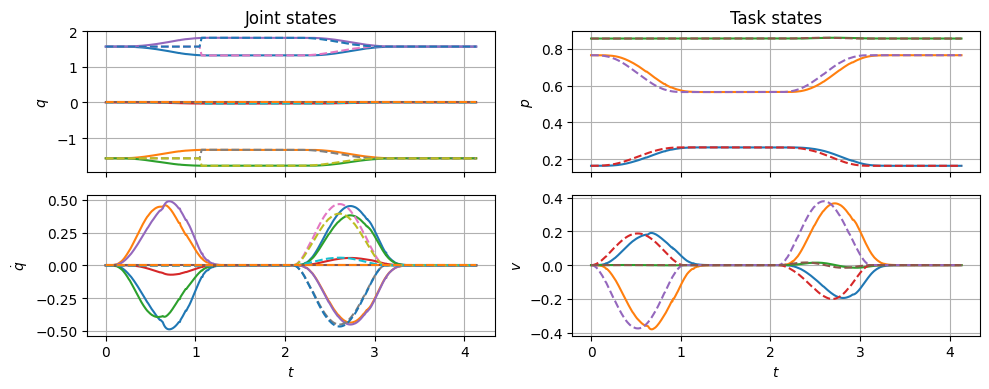

In [13]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(10, 4), sharex=True)

ax[0, 0].plot(tt, qt, "-")
ax[0, 0].plot(tt, rqt, "--")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Joint states")

ax[1, 0].plot(tt, qdt, "-")
ax[1, 0].plot(tt, rqdt, "--")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$\\dot q$")
ax[1, 0].set_xlabel("$t$")

ax[0, 1].plot(tt, xt[:, :3], "-")
ax[0, 1].plot(tt, rxt[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$p$")
ax[0, 1].set_title("Task states")

ax[1, 1].plot(tt, vt[:, :3], "-")
ax[1, 1].plot(tt, rvt[:, :3], "--")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$v$")
ax[1, 1].set_xlabel("$t$")

fig.tight_layout()

#### Joint position forced

In [14]:
r.SetStrategy("JointPositionForced")

In [15]:
r.JMove(r.q_init)
r.Wait(1)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.1, -0.2, 0.0], t=1.0)
r.Wait(1)
r.JMove(r.q_init, t=1.0)
r.Wait(1)
r.StopCapture()

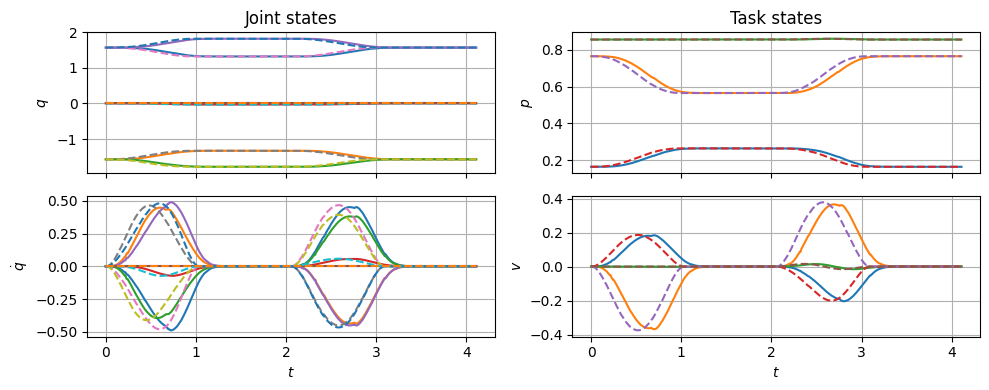

In [16]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(10, 4), sharex=True)

ax[0, 0].plot(tt, qt, "-")
ax[0, 0].plot(tt, rqt, "--")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Joint states")

ax[1, 0].plot(tt, qdt, "-")
ax[1, 0].plot(tt, rqdt, "--")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$\\dot q$")
ax[1, 0].set_xlabel("$t$")

ax[0, 1].plot(tt, xt[:, :3], "-")
ax[0, 1].plot(tt, rxt[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$p$")
ax[0, 1].set_title("Task states")

ax[1, 1].plot(tt, vt[:, :3], "-")
ax[1, 1].plot(tt, rvt[:, :3], "--")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$v$")
ax[1, 1].set_xlabel("$t$")

fig.tight_layout()

#### Cartesian position

In [17]:
r.SetStrategy("CartesianPosition")

In [18]:
r.JMove(r.q_init)
r.Wait(1)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.1, -0.2, 0.0], t=1.0)
r.Wait(1)
r.JMove(r.q_init, t=1.0)
r.Wait(1)
r.StopCapture()

[RBS_WARN] [1773725421.374722004] [ur10]: Not in joint control mode - JMove not executed
[RBS_WARN] [1773725424.448171377] [ur10]: Not in joint control mode - JMove not executed


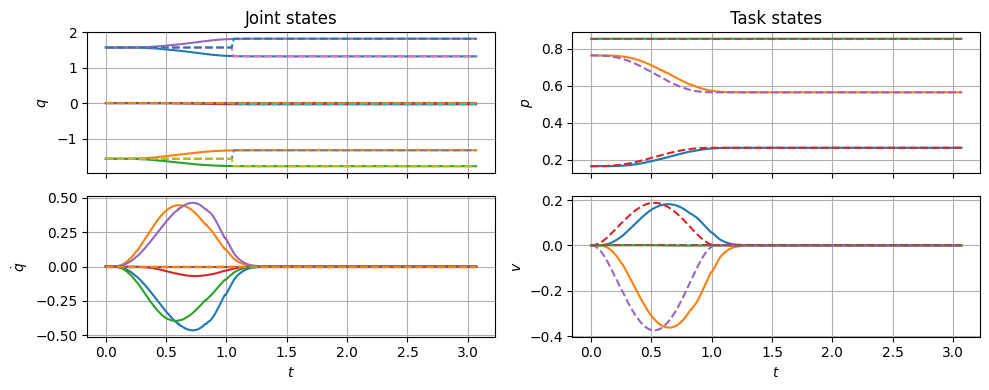

In [19]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(10, 4), sharex=True)

ax[0, 0].plot(tt, qt, "-")
ax[0, 0].plot(tt, rqt, "--")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Joint states")

ax[1, 0].plot(tt, qdt, "-")
ax[1, 0].plot(tt, rqdt, "--")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$\\dot q$")
ax[1, 0].set_xlabel("$t$")

ax[0, 1].plot(tt, xt[:, :3], "-")
ax[0, 1].plot(tt, rxt[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$p$")
ax[0, 1].set_title("Task states")

ax[1, 1].plot(tt, vt[:, :3], "-")
ax[1, 1].plot(tt, rvt[:, :3], "--")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$v$")
ax[1, 1].set_xlabel("$t$")

fig.tight_layout()

## Use internal **ur_rtde** motion control

`JMove(...)` is the joint-space motion command: it moves the robot to a target joint configuration. `CMove(...)` is the Cartesian motion command: it moves the TCP to a target pose. By default, both methods use the Robotblockset motion layer (`_JMove` / `_CMove`), which interpolates the motion and sends RTDE servo commands (`servoJ` / `servoL`) through the active strategy.

If `use_internal=True`, the UR-specific implementation bypasses that outer interpolation layer and calls the UR controller's internal motion generator directly. This is useful when you want the UR controller to execute the move natively.

| Method | Description |
| --- | --- |
| `JMove(q, ..., use_internal=False)` | Joint-space move to target configuration `q`. With `use_internal=False`, Robotblockset generates and executes the motion with the current strategy. With `use_internal=True`, the UR controller executes an internal move: `moveJ` in joint strategy or `moveL_FK` when the active strategy is Cartesian. |
| `CMove(x, ..., use_internal=False)` | Cartesian move to target TCP pose `x`. With `use_internal=False`, Robotblockset interpolates the Cartesian path and sends references through RTDE servoing. With `use_internal=True`, it calls the UR controller's internal Cartesian motion generator `moveL`. |

Comparing the motion using internal motion control with RBS motion control we can see that innternal velocity profiles are alvays trapezoidal and can not be changes as when RBS motion control is used.

In [20]:
r.SetStrategy("JointPosition")

In [21]:
r.JMove(r.q_init, t=1.0, use_internal=True)
r.Wait(1)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.1, -0.2, 0.0], t=1.0, use_internal=True)
r.Wait(1)
r.JMove(r.q_init, t=1.0, use_internal=True)
r.Wait(1)
r.StopCapture()

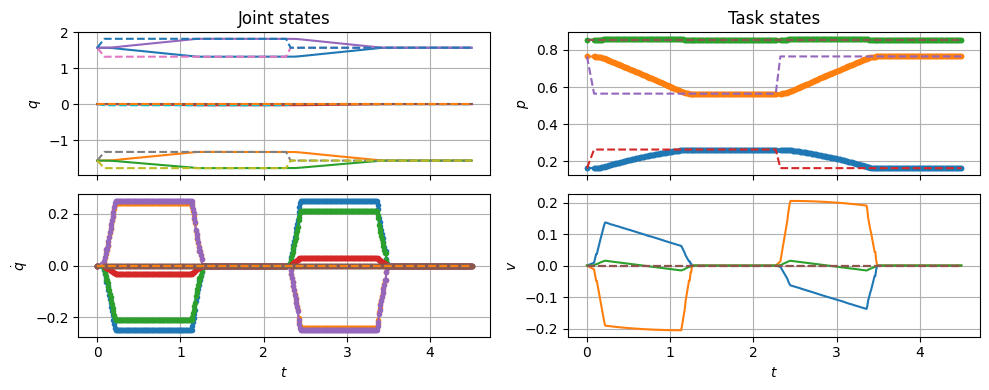

In [22]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(10, 4), sharex=True)

ax[0, 0].plot(tt, qt, "-")
ax[0, 0].plot(tt, rqt, "--")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Joint states")

ax[1, 0].plot(tt, qdt, ".-")
ax[1, 0].plot(tt, rqdt, "--")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$\\dot q$")
ax[1, 0].set_xlabel("$t$")

ax[0, 1].plot(tt, xt[:, :3], ".-")
ax[0, 1].plot(tt, rxt[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$p$")
ax[0, 1].set_title("Task states")

ax[1, 1].plot(tt, vt[:, :3], "-")
ax[1, 1].plot(tt, rvt[:, :3], "--")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$v$")
ax[1, 1].set_xlabel("$t$")

fig.tight_layout()

In [23]:
r.SetStrategy("CartesianPosition")

In [24]:
r.JMove(r.q_init, t=1.0, use_internal=True)
r.Wait(1)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.1, -0.2, 0.0], t=1.0, use_internal=True)
r.Wait(1)
r.JMove(r.q_init, t=1.0, use_internal=True)
r.Wait(1)
r.StopCapture()

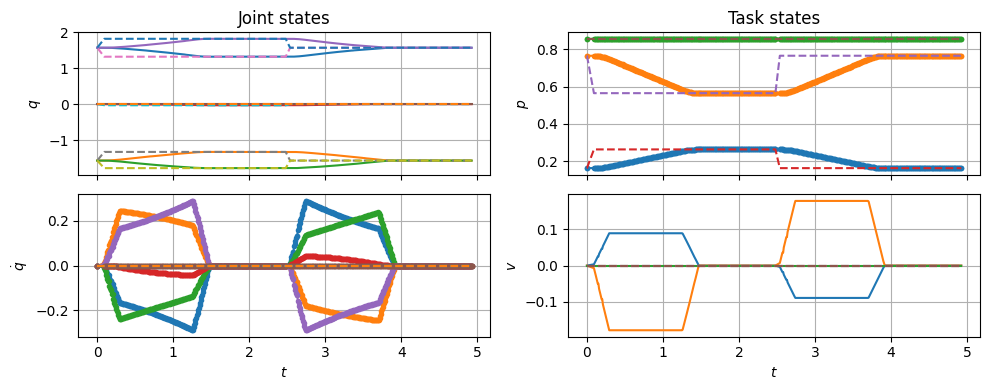

In [25]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(10, 4), sharex=True)

ax[0, 0].plot(tt, qt, "-")
ax[0, 0].plot(tt, rqt, "--")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Joint states")

ax[1, 0].plot(tt, qdt, ".-")
ax[1, 0].plot(tt, rqdt, "--")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$\\dot q$")
ax[1, 0].set_xlabel("$t$")

ax[0, 1].plot(tt, xt[:, :3], ".-")
ax[0, 1].plot(tt, rxt[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$p$")
ax[0, 1].set_title("Task states")

ax[1, 1].plot(tt, vt[:, :3], "-")
ax[1, 1].plot(tt, rvt[:, :3], "--")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$v$")
ax[1, 1].set_xlabel("$t$")

fig.tight_layout()

# Contacts and collisions

UR RTDE does not expose Panda-style collision-threshold configuration through this class. Instead, `robot_ur_rtde` provides contact detection and force-interaction helpers that work with the UR controller and built-in force sensing.

| Method | Description |
| --- | --- |
| `Contacts(direction=(0,0,0,0,0,0))` | Uses UR contact detection and returns the historical joint positions just before contact if contact is detected. |
| `ZeroFTSensor()` | Zeros the built-in TCP force/torque sensor before contact or force interaction tasks. |
| `ForceMode(task_frame, selection, FT, type=2, limits=...)` | Enables UR Cartesian force mode for compliant interaction in a selected task frame. |
| `ForceModeStop()` | Stops force mode, clears related controller popups, reuploads the RTDE script, and resets the current target. |

In [26]:
r.ZeroFTSensor()

# Status and error recovery

The UR status methods are a hardware-aware extension of the generic `robot` interface. Instead of only tracking internal flags, they read the current RTDE and dashboard connection state, decode robot and safety modes, report non-ready conditions such as protective stop or safeguard stop, and provide a direct recovery call for the UR dashboard path.

| Method | Description |
| --- | --- |
| `isConnected()` | Checks the RTDE control, RTDE receive, and dashboard sockets and reports whether all of them are connected. |
| `isReady()` | Returns `True` when the robot is connected and in a motion-ready state according to the decoded UR status. |
| `Check(silent=False)` | Returns a list of active status descriptions. An empty list means no blocking status was detected. |
| `ErrorRecovery()` | Attempts UR-specific recovery. For a protective stop it unlocks the stop through the dashboard client and reuploads the RTDE control script. |

In [27]:
print("Current robot status:", r.Check())

[RBS_INFO] [06:30:39] [ur10]: Robot status:
RobotMode: RUNNING
Active safety flags: none
OK: Robot RUNNING without safety stops.
Current robot status: []


If an error is reported, `ErrorRecovery` can be used for automatic recovery. If this procedure is not successful, the UR dashboard or teach pendant has to be used.

In [28]:
r.ErrorRecovery()

[RBS_INFO] [06:30:39] [ur10]: No errors


True